In [30]:
import sys
import os

In [31]:
# Sube del directorio notebooks a la raiz del proyecto
sys.path.append('../')

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from src.data_processing import load_data

### 1. Carga de Dataframe limpio.

In [33]:
# 1. Cargar dataframe limpio
df_olist = load_data('../data/interim/df_master_clean.csv')

# 2. Cargar la tabla de traduccion original.
df_translation = load_data('../data/raw/product_category_name_translation.csv')

# 3. Realizar el merge para traer el nombre en ingles.
df_olist = pd.merge(df_olist, df_translation, on='product_category_name', how='left')

# 4. Verificar si hay nulos (categorias sin traduccion)
nulos_traduccion = df_olist['product_category_name_english'].isnull().sum()
print(f"Registros sin traduccion: {nulos_traduccion}")

# 5. Llenar nulos con el nombre original si no hay traduccion
df_olist['product_category_name_english'] = df_olist['product_category_name_english'].fillna(df_olist['product_category_name'])

# Verificar que los datos cargaron correctamente
print(f"Dataset cargado con {df_olist.shape[0]} filas y {df_olist.shape[1]} columnas.")
df_olist.head()

Registros sin traduccion: 2567
Dataset cargado con 119137 filas y 49 columnas.


d:\cursos\PENGUIN ACADEMY\CODEPRO 2025\PENGUIN-ACADEMY-BOOTCAMP_02\THE-HATCH\the_hatch_challenge_02\THE_HATCH_DATA_SCIENCE_OLIST_CHALLENGE\notbooks\..\src\data_processing.py:6: DtypeWarning: Columns (32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state,geolocation_zip_code_prefix_vendor,geolocation_lat_vendor,geolocation_lng_vendor,geolocation_city_vendor,geolocation_state_vendor,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,-23.576983,-46.587161,sao paulo,SP,9350.0,-23.680729,-46.444238,maua,SP,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,-23.576983,-46.587161,sao paulo,SP,9350.0,-23.680729,-46.444238,maua,SP,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,-23.576983,-46.587161,sao paulo,SP,9350.0,-23.680729,-46.444238,maua,SP,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,595fac2a385ac33a80bd5114aec74eb8,...,-12.177924,-44.660711,barreiras,BA,31570.0,-19.807681,-43.980427,belo horizonte,MG,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,aa4383b373c6aca5d8797843e5594415,...,-16.745150,-48.514783,vianopolis,GO,14840.0,-21.363502,-48.229601,guariba,SP,auto


### 2. Analisis exploratorio EDA.

A) Heatmap de Afinidad entre Categorias.
+ No queremos ver solo lo que se vende, sino que se vende junto.
+ Usaremos una matriz de co-ocurrencia para ver la afinidad entre categorias principales.

C:\Users\william\AppData\Local\Temp\ipykernel_21068\1506557562.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pivot_binary = pivot_categories.applymap(lambda x:1 if x > 0 else 0)


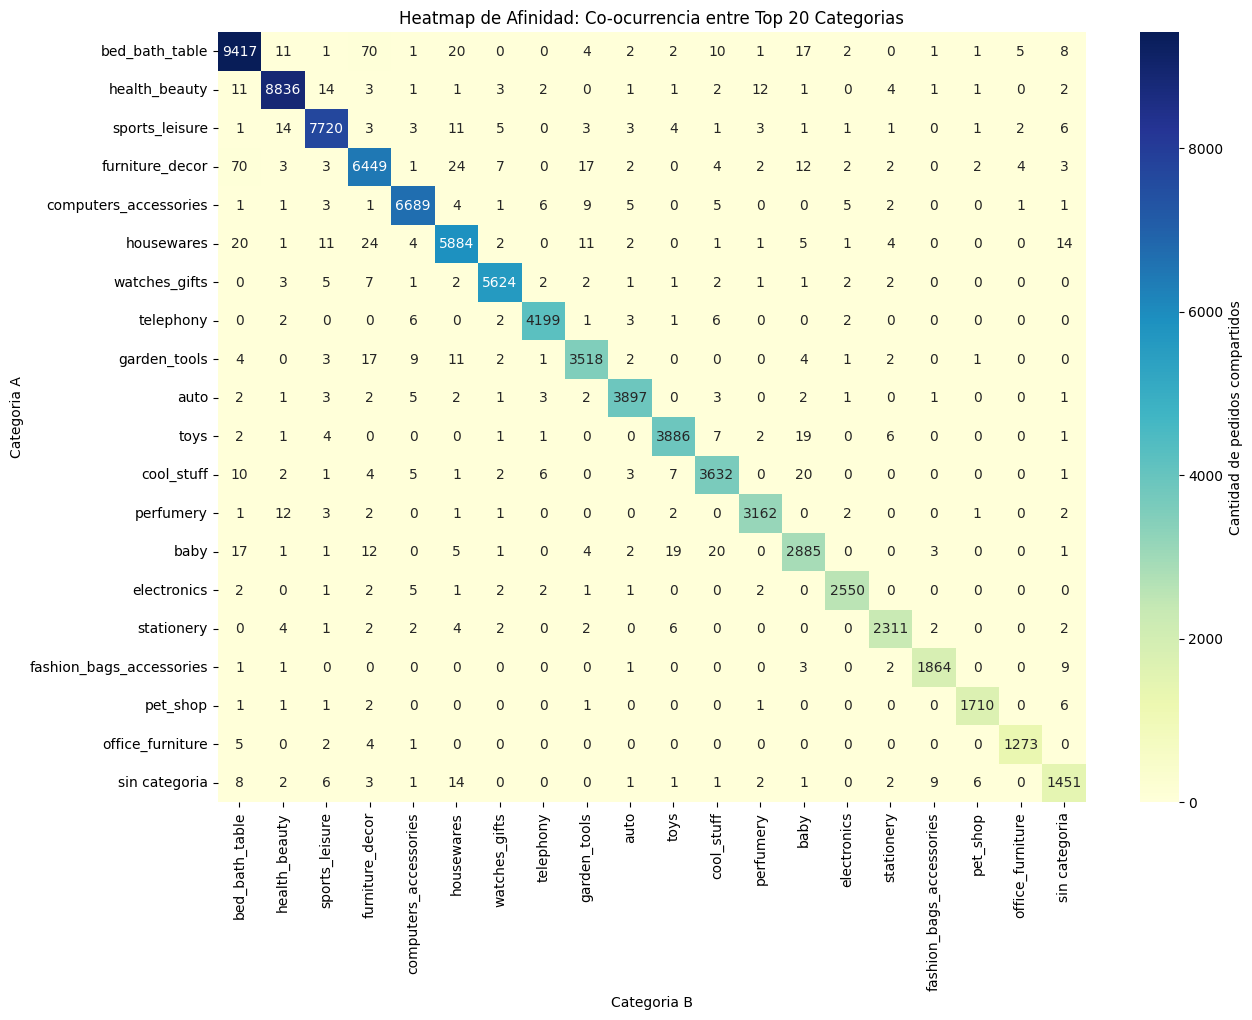

In [34]:
# 1. Crear una tabla de 'pedidos vs categorias'
# Cada fila es un pedido y cada columna una categoria, con el conteo de productos.
# Resultado: Crea grupo donde cada grupo contiene todos los productos de una misma categoria que pertenen a un mismo pedido.
# .size() : cuenta cuantos productos hay en cada categoria.
# .unstack(): toma la columna de categorias y la desapila convirtiendola en los encabezados de las columnas.
# fill_value=0 : si un pedido no tiene productos de una categoria espesifica, pandas pondria una valor vacio (NaN). Cambia esos vacios por un 0.
pivot_categories = df_olist.groupby(['order_id', 'product_category_name_english']).size().unstack(fill_value=0)

# Convertir a binario (1 si el pedido tiene la categoria, 0 si no)
# x :  representa la cantidad de productos de una categoria en un pedido.
# condicion :  si el valor x es mayor a 0 (es decir el cliente compro al menos un articulo de esa categoria) lo convierte en 1, si no en 0
pivot_binary = pivot_categories.applymap(lambda x:1 if x > 0 else 0)

# 2. Calcular la matriz de Co-ocurrencia.
# Multiplicamos la matriz transpuesta por si misma para ver cuantas veces coinciden.
co_occurrence_matrix = pivot_binary.T.dot(pivot_binary)

# 3. Seleccionar la top 20 categorias para que el grafico sea legible.
top_20_categories = df_olist['product_category_name_english'].value_counts().head(20).index
matrix_subset = co_occurrence_matrix.loc[top_20_categories, top_20_categories]

# 4. Generar el Heatmap.
plt.figure(figsize=(14,10))
sns.heatmap(matrix_subset, annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'Cantidad de pedidos compartidos'})
plt.title('Heatmap de Afinidad: Co-ocurrencia entre Top 20 Categorias')
plt.xlabel('Categoria B')
plt.ylabel('Categoria A')
plt.show()




### 3. Preparacion para el clustering.

El Heatmap nos mostró que muchas categorías se compran de forma independiente, el Clustering nos ayudará a encontrar patrones basados en el "perfil" del producto (precio, calidad y popularidad).

+ Crear una tabla resumen por **Producto** y normalizar los valores.





In [35]:
# 1. Creacion de la tabla de caracteristicas (Features)
# Agrupamos por producto para obtener su perfil promedio.
df_items_cluster = df_olist.groupby('product_id').agg({
    'price': 'mean',
    'review_score': 'mean',
    'order_id': 'count'
}).rename(columns={'order_id': 'popularity'})

# Eliminamos posibles nulos que hayan quedado en los scores.
df_items_cluster = df_items_cluster.dropna()

print(f"Total de productos unicos para cluster: {df_items_cluster.shape[0]}")

Total de productos unicos para cluster: 32789


In [36]:
df_items_cluster.head()

,price,review_score,popularity
product_id,,,
00066f42aeeb9f3007548bb9d3f33c38,101.65,5.0,1
00088930e925c41fd95ebfe695fd2655,129.90,4.0,1
0009406fd7479715e4bef61dd91f2462,229.00,1.0,1
000b8f95fcb9e0096488278317764d19,58.90,5.0,2
000d9be29b5207b54e86aa1b1ac54872,199.00,5.0,1


In [37]:
from sklearn.preprocessing import StandardScaler

# 2. Estandarizacion de datos (StandardScaler)

# Consite en modificar los valores de las columnas price, review_score y popularity para evitar que el algoritmo K-Means no se equivoque en elegir la importancia
# de los valores por diferencia de numeros mas grandes. StandardScaler cambia el rango de los valores para que los numeros esten en un rango similar, entre (-3 y 3)
# Con esto evitamos que los precios dominen toda la logica del proyecto, pues son los valores mas grandes.

scaler = StandardScaler()  # Defino el objeto scaler.

# Seleccionamos las columnas numericas.
features = ['price', 'review_score', 'popularity']  # Defino las columnas a modificar
df_scaled = scaler.fit_transform(df_items_cluster[features])  # Transformo los valores de las columnas features.

# Lo convertimos de nuevo a un DataFrame para manejarlo mejor.
df_scaled = pd.DataFrame(df_scaled, columns=features, index=df_items_cluster.index)
df_scaled.head()

,price,review_score,popularity
product_id,,,
00066f42aeeb9f3007548bb9d3f33c38,-0.177996,0.783552,-0.234334
00088930e925c41fd95ebfe695fd2655,-0.062436,-0.039104,-0.234334
0009406fd7479715e4bef61dd91f2462,0.342942,-2.507071,-0.234334
000b8f95fcb9e0096488278317764d19,-0.352869,0.783552,-0.144256
000d9be29b5207b54e86aa1b1ac54872,0.220224,0.783552,-0.234334


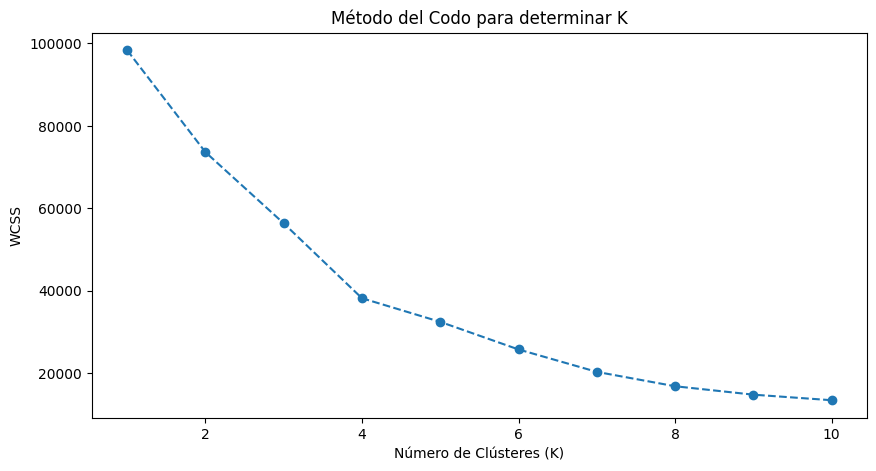

In [38]:
# 3. Decidir cuantos clusteres (k) son ideales. Metodo del codo (Elbow Method)

# Si son demasiado seria confuso.
# Si son muy pocos perderiamos detalle.

# Objetivo: responder a la pregunta. ¿En cuantos grupos (clusters) debemos dividir nuestros productos?

from sklearn.cluster import KMeans

'''
WCSS (Within-Cluster Sum of Squares) "Sumna de los cuadrados dentro de los clusters

Es una metrica que mide que tan compactos o unidos estan los puntos dentro de sus grupos

* Si el WCSS es bajo: los productos dentro de cada grupo estan muy cerca unos de otros (buen agrupamiento)
* Si el WCSS es alto: los grupos estan muy dispersos
'''
wcss = []   


for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Graficamos el Codo
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Método del Codo para determinar K')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('WCSS')
plt.show()


In [39]:
# Entrenamos el modelo final con K=4
kmeans_final = KMeans(n_clusters=4, init='k-means++', random_state=42)

# CAMBIO: Usamos fit_predict para obtener las etiquetas (0, 1, 2, 3)
df_items_cluster['cluster'] = kmeans_final.fit_predict(df_scaled)

# Ahora sí podemos revisar el tamaño de cada grupo
print("Cantidad de productos por clúster:")
print(df_items_cluster['cluster'].value_counts())

# Y ver las características promedio
print("\nPromedio de características por clúster:")
print(df_items_cluster.groupby('cluster').mean())

Cantidad de productos por clúster:
cluster
1    24831
0     6940
3      931
2       87
Name: count, dtype: int64

Promedio de características por clúster:
               price  review_score  popularity
cluster                                       
0         120.672626      2.049761    2.257925
1         111.515541      4.600916    3.484435
2          94.554848      4.015522  160.068966
3        1229.885096      4.183181    2.116004


### Construir el motor de recomendaciones

In [40]:
# 1. Preparacion: Mapeo de Categorias.
# Unimos la categoria al dataframe de clusteres.
df_recommendations = df_items_cluster.copy()
df_cat_mapping = df_olist[['product_id', 'product_category_name_english']].drop_duplicates()
df_recommendations = df_recommendations.merge(df_cat_mapping, on='product_id', how='left')

In [41]:
# 2. Funcion de recomendacion
# Este codigo buscara productos "hermanos" dentro del mismo grupo.

def recomendar_productos(product_id, n_recomendaciones=3):
    # 1. Obtener el clúster y categoría del producto de referencia
    prod_info = df_recommendations[df_recommendations['product_id'] == product_id]
    
    if prod_info.empty:
        return "Producto no encontrado en la base de datos."
    
    cluster_id = prod_info['cluster'].values[0]
    categoria = prod_info['product_category_name_english'].values[0]
    
    # 2. Filtrar otros productos del mismo clúster
    # Priorizamos misma categoría, si no hay, buscamos en el mismo clúster
    candidatos = df_recommendations[
        (df_recommendations['cluster'] == cluster_id) & 
        (df_recommendations['product_id'] != product_id)
    ]
    
    # 3. Ordenar por los mejores (Review Score y Popularidad)
    recomendaciones = candidatos.sort_values(
        by=['review_score', 'popularity'], 
        ascending=False
    ).head(n_recomendaciones)
    
    return recomendaciones[['product_id', 'product_category_name_english', 'price', 'review_score']]

In [42]:
# 3. Prueba del sistema.
# Copia un product_id de tu dataset (especialmente uno del Clúster 2, que son los "Best Sellers") y ejecútalo así

# Ejemplo con un ID de tu tabla
ejemplo_id = df_recommendations.iloc[0]['product_id']
print(f"Si compraste el producto: {ejemplo_id}")
print("\nTe recomendamos estos similares:")
recomendar_productos(ejemplo_id)

Si compraste el producto: 00066f42aeeb9f3007548bb9d3f33c38

Te recomendamos estos similares:


,product_id,product_category_name_english,price,review_score
30230,ebf9bc6cd600eadd681384e3116fda85,bed_bath_table,12.99,5.0
639,0554911df28fda9fd668ce5ba5949695,office_furniture,79.99,5.0
12098,5ddab10d5e0a23acb99acf56b62b3276,housewares,83.80,5.0
